# Analyse PE samples review
Notebook to analyse the PE samples. Starts by reading in the correct config and backend files from the correct sampling directory. Then it unpacks the loglikelihood and we can assess the convergence based on the loglikelihood and the traces of the deviation for each sampled parameter. That should look like gaussian, stationary noise, otherwise the sampler has not converged yet and we need to take more samples. 

The notebook produces some plots showing the results. First two corner plots, one with and and one without the extrisic parameters. Then two plots to determine the convergence: one of the evolution of the estimated variance (=diagonal element of covariance matrix) for each parameter, and one with the Gelman-Rubin criterion for convergence. 

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.size'] = 14

from src.io import param_load
from src.analysis import (
    sampled_params_from_config,
    load_samples,
    load_samples_named,
    plot_log_like,
    cut_samples_autocorr,
    filter_lost_walkers,
    corner_plot,
    plot_sky_position,
    plot_chain_convergence,
    plot_covariance_evolution,
    plot_gelman_rubin,
    plot_seaborn_diagnostics,
)

## Define samples

In [2]:
# define PE run settings
src_index = 10
inj = '1PA'
rec = '0PA'
eps = 'e-4'
addition = '' #'_amps'

# Post-processing
do_filter_lost   = False  # remove lost walkers
do_thin          = False  # thin by integrated auto-correlation time to exclude correlated samples
exclude_sky      = False  # exclude sky-angle params from the intrinsic corner plot

# Threshold for lost walker detection 
# This only applies to the cold chain
lost_lower_bound = -30.0

# Colour for this run's posterior in overlay plots
posterior_color  = 'maroon'

In [3]:
sampling_dir = f'{os.getcwd()}/scripts/sampling_data'

In [4]:
run_dir = os.path.join(sampling_dir, 'Review_test_1_inj_1PA_rec_1PA_2026-08-27_16-11-32')
print(f'Using run directory: {run_dir}')

# Find the HDF5 backend file inside
h5_files = glob.glob(os.path.join(run_dir, 'SamplingResults_*.h5'))
if not h5_files:
    raise FileNotFoundError(f'No HDF5 file found in {run_dir}')
file_path = h5_files[0]
print(f'Loading: {file_path}')

Using run directory: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/scripts/sampling_data/Review_test_1_inj_1PA_rec_1PA_2026-08-27_16-11-32
Loading: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/scripts/sampling_data/Review_test_1_inj_1PA_rec_1PA_2026-08-27_16-11-32/SamplingResults_Review_test_1_inj_1PA_rec_1PA_fixedx_I0_1.0_e0_0.0_Phi_theta0_6.13001602516006_Phi_r0_4.782381792256834_2026-08-27_16-11-32.h5


In [5]:
# new structure copies config file into the directory
conf_file = glob.glob(os.path.join(run_dir, '*.yaml'))

if not conf_file:
    raise FileNotFoundError(f'No HDF5 file found in {run_dir}')
config_file_path = conf_file[0]
config = param_load(config_file_path)

emri   = config['Injection']['EMRI']
inj_wf = config['Injection']['Waveform']
rec_wf = config['Recovery']['Waveform']

amps_toggle = config['Recovery']['Waveform']['include_1PA_amps']
evolution_primary_toggle = config['Recovery']['Waveform']['evolve_chi1']

print(f"Injection model : {inj_wf['model']}")
print(f"Recovery model  : {rec_wf['model']} \n 1PA amps {amps_toggle}, evolution primary {evolution_primary_toggle}")
print(f"Fixed params    : {config['Sampler'].get('fixed_params', [])}")
print()
print('EMRI injection parameters')
print('=' * 32)
for k, v in emri.items():
    print(f'  {k:<16} {v}')
    
print('=' * 32)
print(f'Mass-ratio m2 / m1= {emri['mu'] / emri['M']:.2e}')

Injection model : 1PAT1R
Recovery model  : 0PA_Kerr 
 1PA amps False, evolution primary False
Fixed params    : ['x_I0', 'e0', 'Phi_theta0', 'Phi_r0']

EMRI injection parameters
  M                4975124.504066709
  mu               99.50249008133419
  a                8.2e-05
  p0               8.8123
  e0               0.0
  chi2             0.5
  x_I0             1.0
  d_L              0.022213015032605164
  theta_S          2.4314546363447995
  phi_S            2.757554564287996
  theta_K          2.6973649175810768
  phi_K            4.381692553882582
  Phi_phi0         0.5917337285168199
  Phi_theta0       6.13001602516006
  Phi_r0           4.782381792256834
  z                0.004999974556005059
Mass-ratio m2 / m1= 2.00e-05


In [6]:
param_names, true_vals = sampled_params_from_config(config)

print(f'Sampled parameters ({len(param_names)}):')
for name, val in zip(param_names, true_vals):
    print(f'  {name:<16} {val}')

Sampled parameters (10):
  M                5000000.0
  mu               100.0
  a                8.2e-05
  p0               8.8123
  d_L              0.022213015032605164
  theta_S          2.4314546363447995
  phi_S            2.757554564287996
  theta_K          2.6973649175810768
  phi_K            4.381692553882582
  Phi_phi0         0.5917337285168199


In [10]:
discard= 2000   # burn-in iterations to discard

In [11]:
# Load samples and log-likelihoods from the HDF5 backend file
samples_per_temp, reader, log_like, (N_iters, N_temps, N_walkers, N_params) = \
    load_samples(file_path, discard=discard)

print(f'Shape: {N_iters} iters  x  {N_temps} temps  x  {N_walkers} walkers  x  {N_params} params')

Shape: 1537 iters  x  1 temps  x  70 walkers  x  10 params


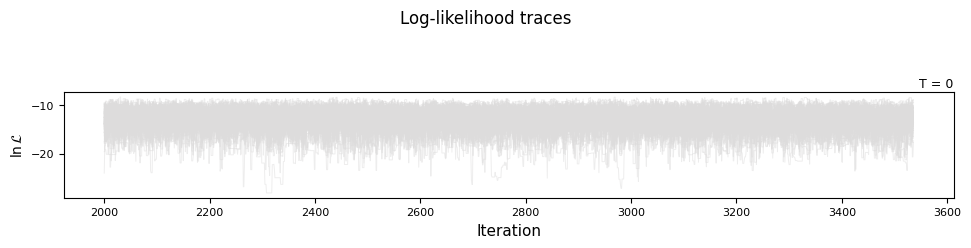

In [12]:
plot_log_like(log_like, temps=list(range(N_temps)), discard=discard)
plt.show()

Removed 0/70 lost walkers (lower_bound=-2400.0).


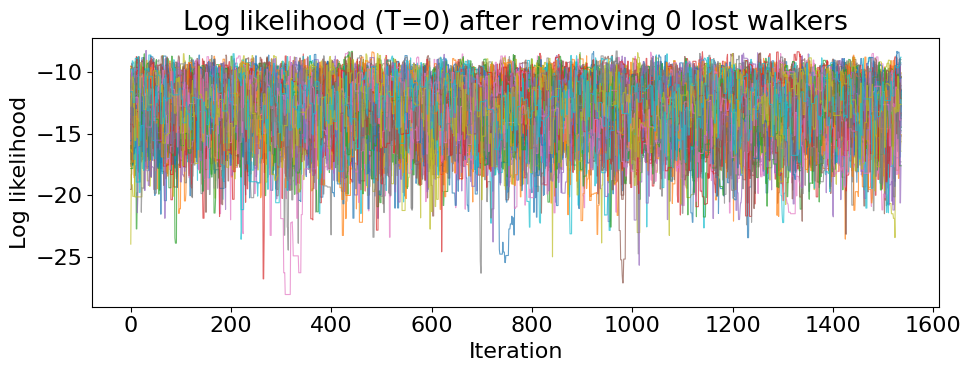

Cold chain after filtering: (107590, 10)


In [13]:
# if the lgglikelihood shows lost walkers, we filetr these out from the cold chain
do_filter_lost=True
if do_filter_lost:
    clean_samples, kept_idx, ll_clean = filter_lost_walkers(
        reader, discard=discard, lower_bound=-2400
    )
    # Replace cold-chain samples with the filtered version
    samples_per_temp[0] = clean_samples
    print(f'Cold chain after filtering: {clean_samples.shape}')
else:
    print('Skipping lost-walker filtering.')

In [14]:
if do_thin:
    samples_per_temp = cut_samples_autocorr(reader, samples_per_temp, discard=discard)
    print(f'Thinned cold chain: {samples_per_temp[0].shape}')
else:
    print('Skipping autocorrelation thinning.')

Skipping autocorrelation thinning.


### Verify chain convergence
A stable loglikelihood trace indicates that the chains have converged. However, proper convergence diagnostics are needed to confirm this. We plot the loglikelihood trace for the cold chain (T=0) to visually inspect its behavior over iterations. A stable and well-mixed trace suggests good convergence, while trends or large fluctuations point to issues with convergence.

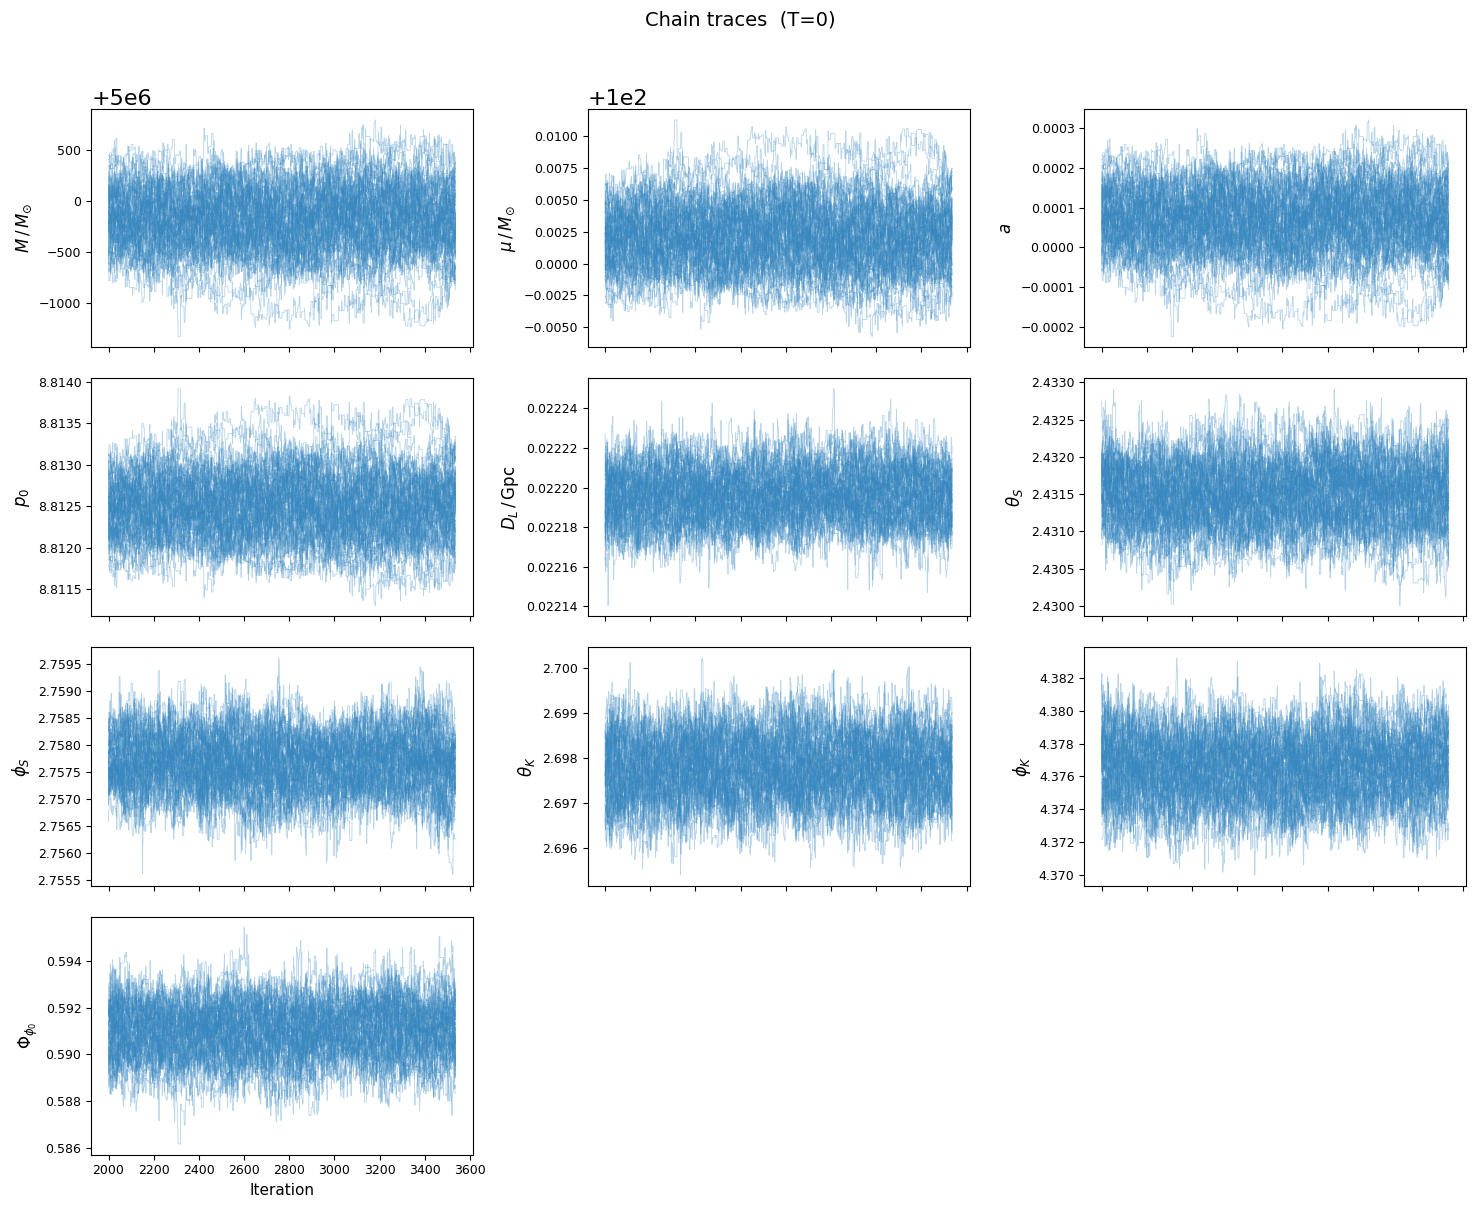

In [15]:
fig = plot_chain_convergence(
    reader, param_names,
    discard=discard, temp=0,
    # plot_name=plot_name_traces,
)

## Corner plot
Create corner plot kto inspect the posterior distributions of parameters and their correlations

In [16]:
true_vals

array([5.00000000e+06, 1.00000000e+02, 8.20000000e-05, 8.81230000e+00,
       2.22130150e-02, 2.43145464e+00, 2.75755456e+00, 2.69736492e+00,
       4.38169255e+00, 5.91733729e-01])

In [17]:
include_prior_bounds = True
if include_prior_bounds:
    from src.priors import build_priors

    # Match the call used by sample.py
    fixed_names = list(config['Sampler'].get('fixed_params', []) or [])
    _, bounds, _ = build_priors(
        param_names, true_vals, fixed_names,
        n=float(config['Sampler']['d']),
        use_cupy=False,                     # no GPU needed for bounds
    )
    prior_bounds = {n: bounds[k] for k, n in enumerate(param_names)}


In [18]:
prior_bounds

{'M': (np.float64(4930000.0), np.float64(5070000.0)),
 'mu': (2.0, np.float64(200.0)),
 'a': (np.float64(-0.099918), np.float64(0.100082)),
 'p0': (np.float64(-1.1876999999999995), np.float64(18.8123)),
 'd_L': (0.001, np.float64(5.022213015032605)),
 'theta_S': (0.0, 3.141592653589793),
 'phi_S': (0.0, 6.283185307179586),
 'theta_K': (0.0, 3.141592653589793),
 'phi_K': (0.0, 6.283185307179586),
 'Phi_phi0': (0.0, 6.283185307179586)}

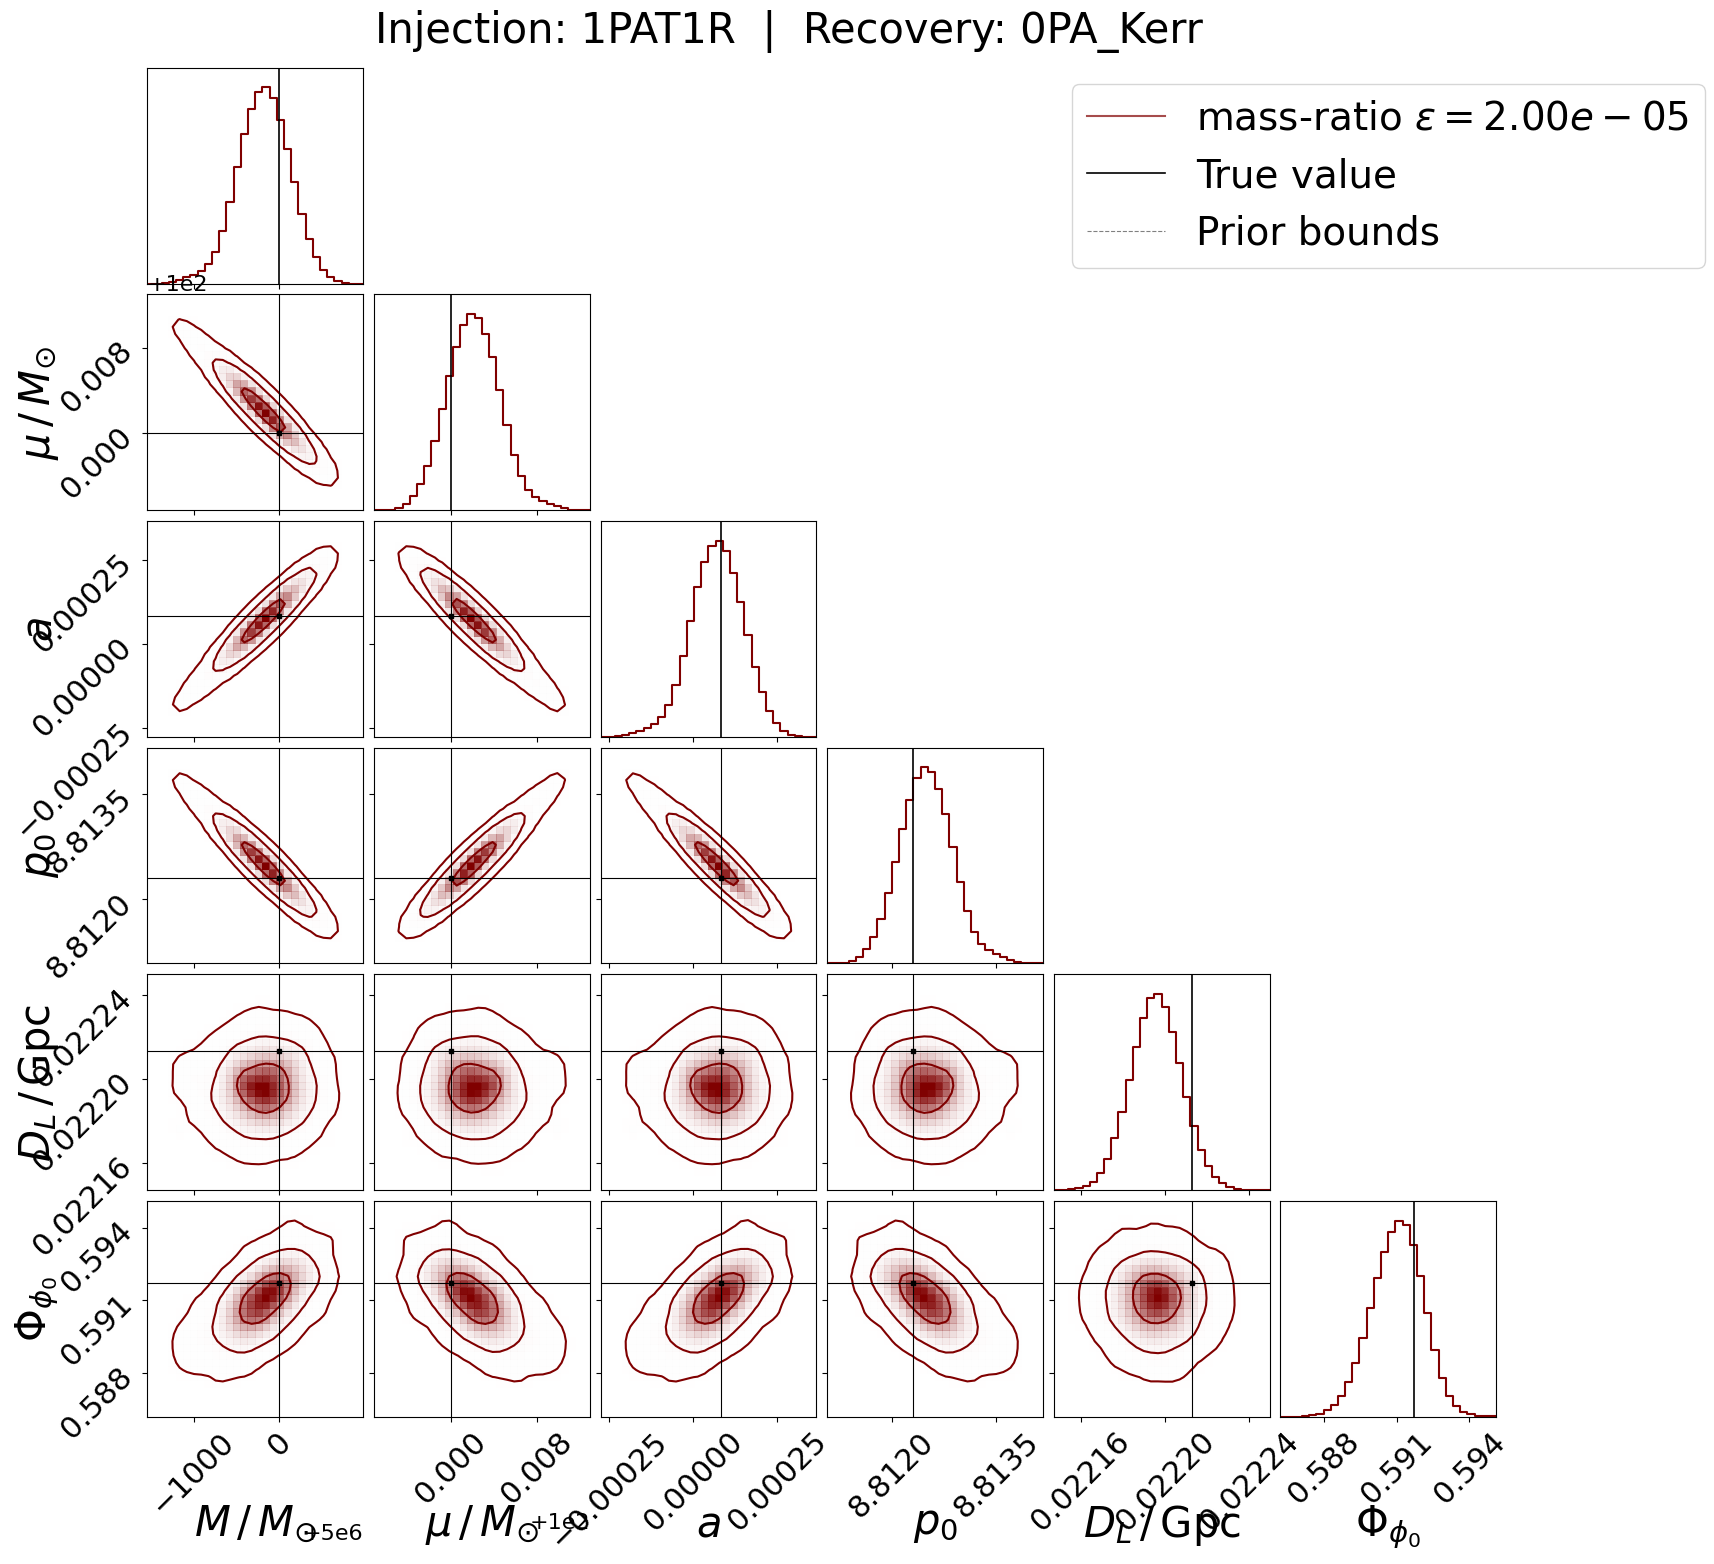

In [19]:
# samples_dict: key = legend label; value = dict with 'color' and 'samples'.
# Add extra entries here to overlay additional posteriors (e.g. higher temps).
samples_dict = {
    rf"mass-ratio $\epsilon = {emri['mu'] / emri['M']:.2e}$": {
        'color':   posterior_color,
        'samples': samples_per_temp[0],
    },
}

plot_name_intrinsic = f'{run_dir}/Review_1PAT1R_test1'

fig = corner_plot(
    samples_dict,
    true_vals,
    param_names,
    inj_model=inj_wf['model'],
    rec_model=rec_wf['model'],
    exclude_sky=True,          # intrinsic + phases only
    plot_name=plot_name_intrinsic,
    range_overrides={
        'M':  1.2,         
        'mu': 1.2,   
        'a': 1.2,
        'p0': 1.2,
        'chi2': 1.0
    },
    prior_bounds=prior_bounds,
    save_dpi=100
)
plt.show()

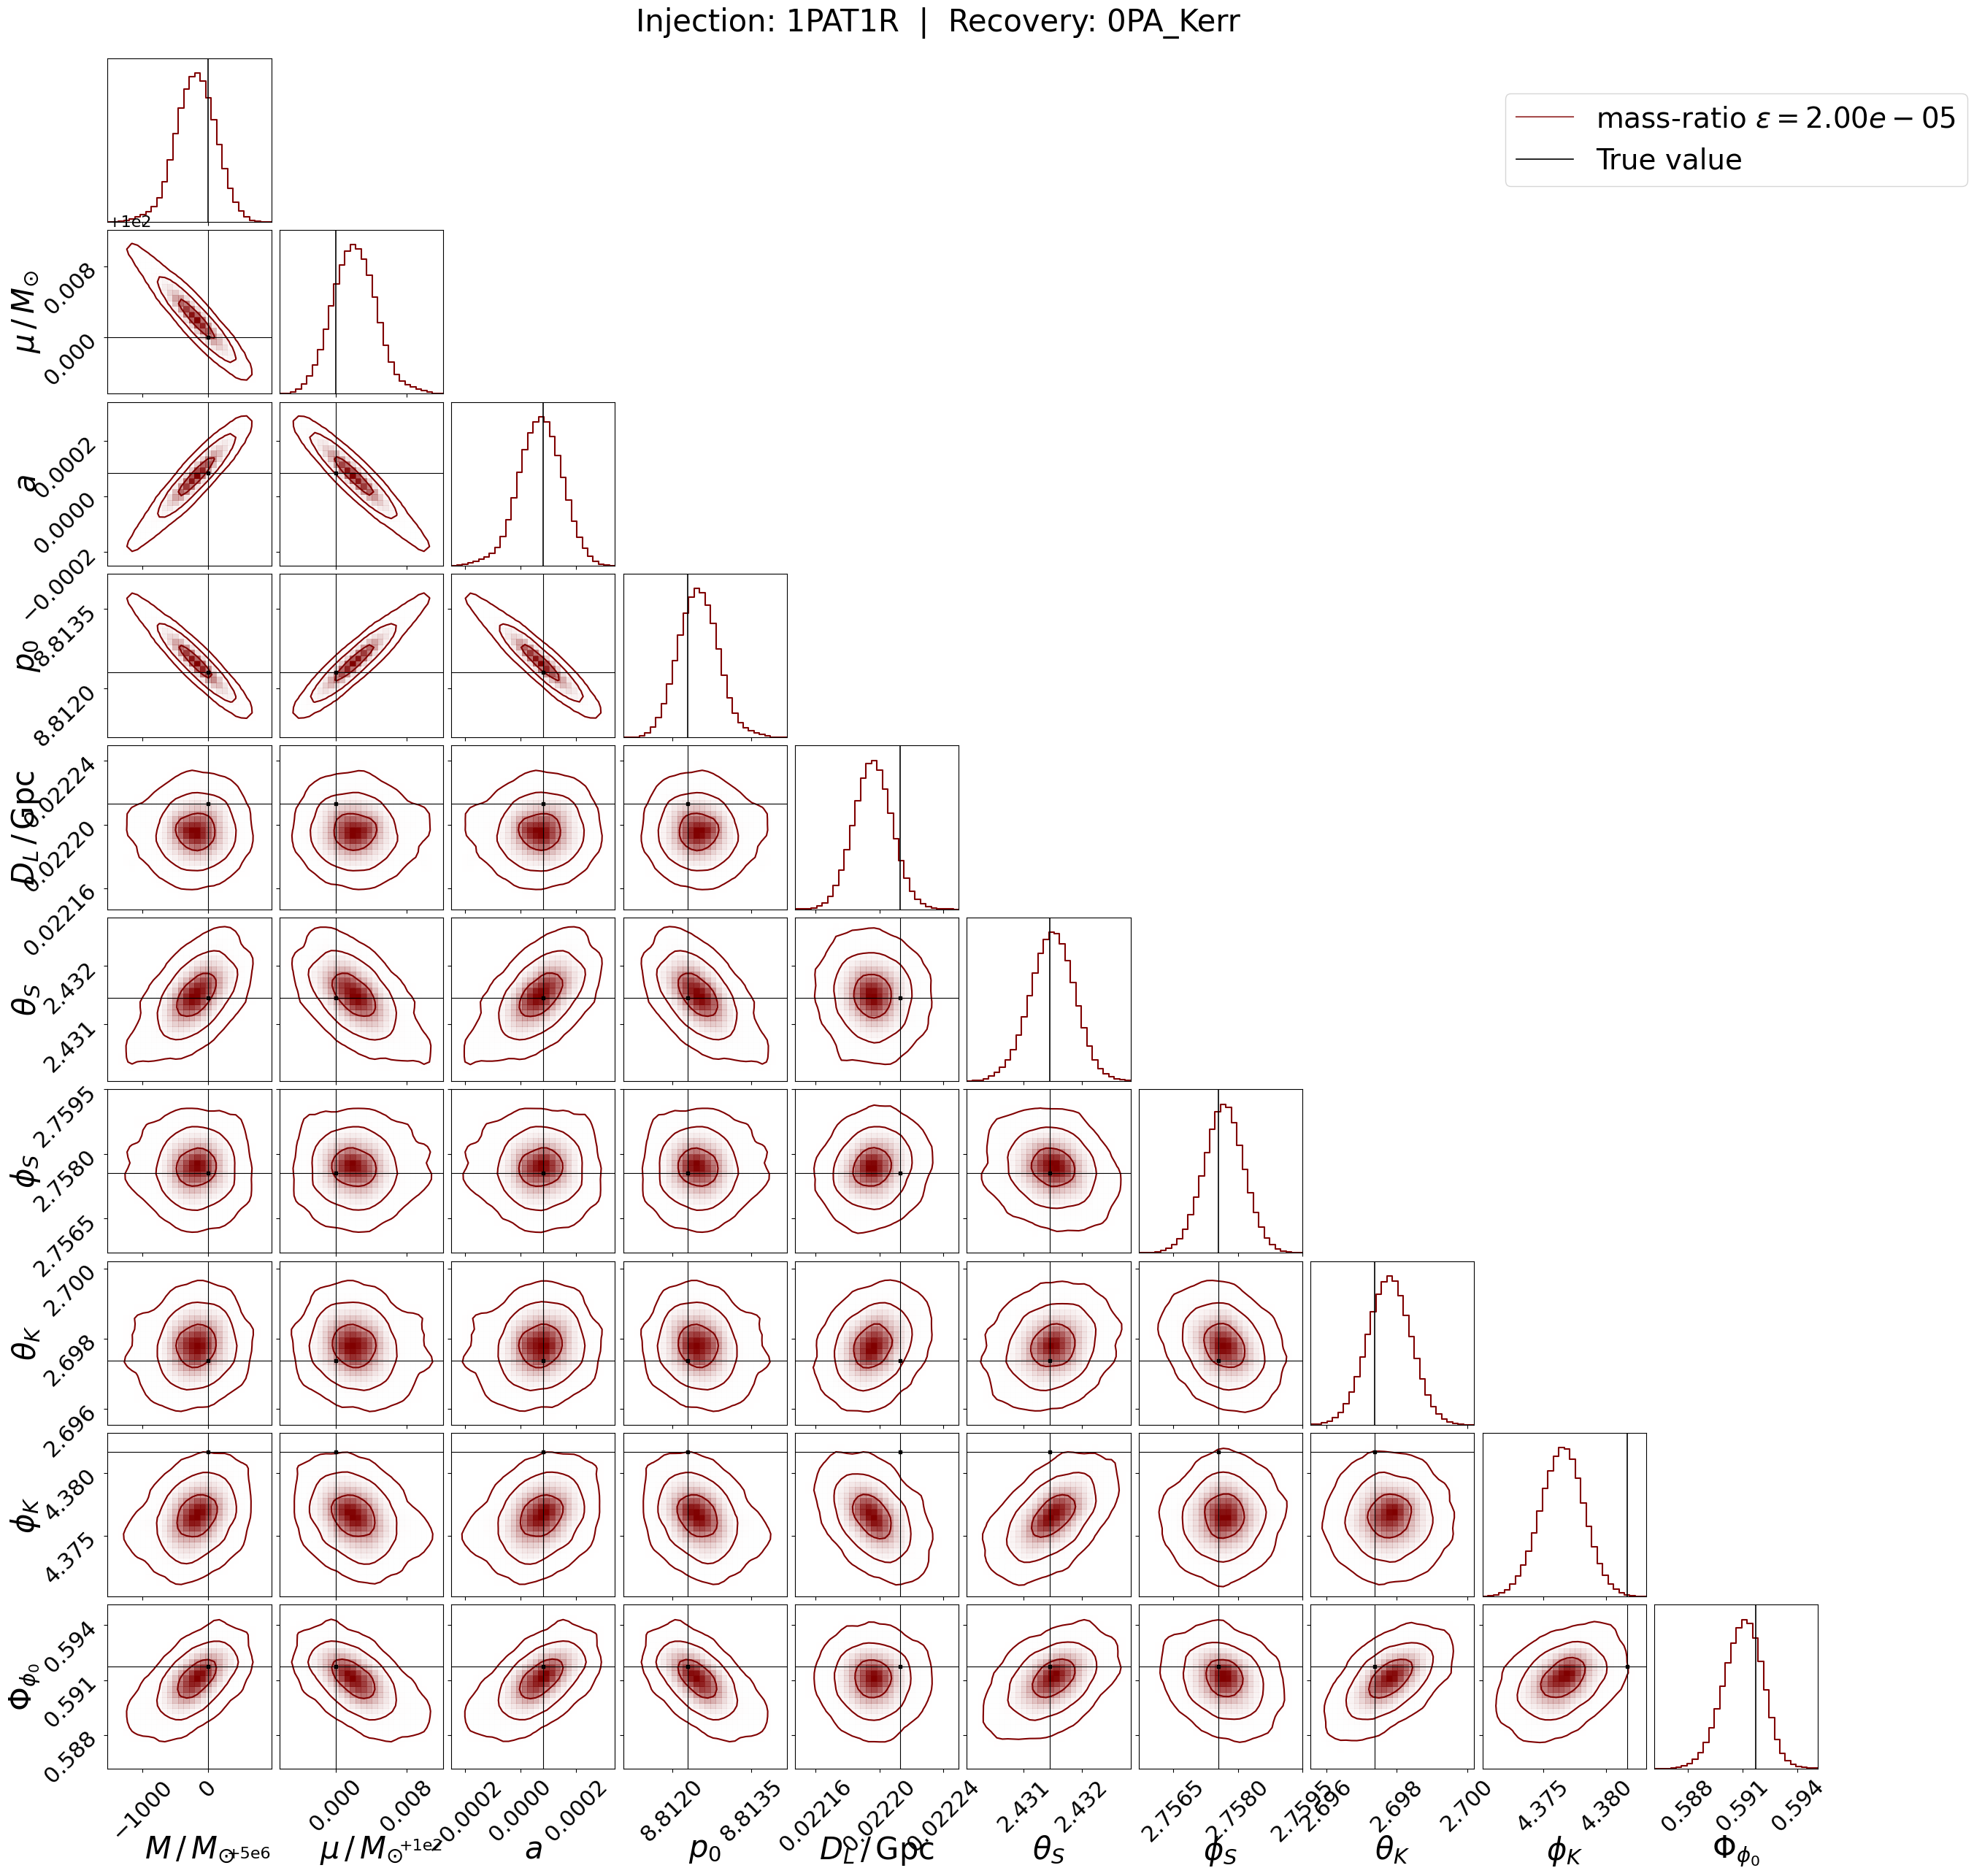

In [22]:
# Full corner plot including sky-angle parameters
plot_name_full = f'{run_dir}/MH_{src_index}_corner_full'
fig = corner_plot(
    samples_dict,
    true_vals,
    param_names,
    inj_model=inj_wf['model'],
    rec_model=rec_wf['model'],
    exclude_sky=False,
    plot_name=plot_name_full,
    range_overrides={
        'M':  1.2,         
        'mu': 1.1,   
        'a': 1.1,
        'p0': 1.2,
        'chi2': 1.0
    },
    save_dpi=60
)
plt.show()

If semi-latus rectum and primary mass are completely degenerate, that indicates the injected signal does not have any chirp at all.  

What happened in the secondary mass? Why is this behaving weird? The signal shows some chirp but is not plunging within 2 years. There is only slight curvature of the tracks, that may not be enough to break the degeneracy of the mass-ratio. Also the primary mass is not very well resolved. 

In [19]:
cold_samples = samples_per_temp[0]   # (N_samples, N_params)

rows = []
for k, name in enumerate(param_names):
    col   = cold_samples[:, k]
    med   = np.median(col)
    lo68, hi68 = np.percentile(col, [16.0, 84.0])
    lo90, hi90 = np.percentile(col, [ 5.0, 95.0])
    half_68    = (hi68 - lo68) / 2.0
    bias_sigma = (med - true_vals[k]) / half_68 if half_68 > 0 else float('nan')
    in_90ci    = lo90 <= true_vals[k] <= hi90
    rows.append(dict(
        name       = name,
        true       = true_vals[k],
        median     = med,
        lo68       = lo68,
        hi68       = hi68,
        ci90_width = hi90 - lo90,
        bias_sigma = bias_sigma,
        in_90ci    = in_90ci,
    ))

header = (f"{'Param':<16}  {'True':>12}  {'Median':>12}  "
          f"{'[16th':>12}  {'84th]':>12}  {'90% CI':>10}  {'bias/σ':>7}  {'in 90%CI':>9}")
sep = "-" * len(header)
print(header)
print(sep)
for r in rows:
    flag = "yes" if r['in_90ci'] else "NO"
    print(f"{r['name']:<16}  {r['true']:>12.5g}  {r['median']:>12.5g}  "
          f"{r['lo68']:>12.5g}  {r['hi68']:>12.5g}  {r['ci90_width']:>10.4g}  "
          f"{r['bias_sigma']:>7.2f}  {flag:>9}")
print(sep)
print(f"\n{'N cold samples:':<20} {len(cold_samples)}")


Param                     True        Median         [16th         84th]      90% CI   bias/σ   in 90%CI
--------------------------------------------------------------------------------------------------------
M                      2.5e+06         2e+06         2e+06         2e+06       69.54  -24912.41         NO
mu                        2500          2000          2000          2000    0.008899  -149894.82         NO
a                        0.002     0.0020048      0.001983     0.0020259   7.372e-05     0.22        yes
p0                          23            23            23            23   0.0004619    -0.22        yes
chi2                       0.9       0.90003       0.89652       0.90347    0.008997     0.01        yes
d_L                          5        4.9965        4.9411        5.0539      0.1791    -0.06        yes
theta_S                0.56891        0.5687       0.55559       0.58246     0.04471    -0.02        yes
phi_S                   3.0696        3.0727      

## Plots for review tests

In [23]:
sampling_dir

'/vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/scripts/sampling_data'

### Test 1: spin out of accurate regime

In [24]:
index = 1

In [25]:
# hardcoded path
full_1PA = f'{sampling_dir}/Review_test_1_inj_1PA_rec_1PA_2026-08-27_00-29-21'

# Load configs for each run to derive the correct parameter lists
config_full_1PA = param_load(glob.glob(os.path.join(full_1PA, '*.yaml'))[0])


# Derive sampled parameters
param_names_full, injected_vals = sampled_params_from_config(config_full_1PA)
print(f'Full 1PA params ({len(param_names_full)}): {param_names_full}')

# Locate HDF5 backends using the hard-coded paths
h5_full = glob.glob(os.path.join(full_1PA, 'SamplingResults_*.h5'))

# Validation and Loading
for label, h5_list in zip(['Full'], [h5_full]):
    if not h5_list:
        raise FileNotFoundError(f'No HDF5 found for {label} run.')
    print(f'\nLoading {label}: {h5_list[0]}')

Full 1PA params (11): ['M', 'mu', 'a', 'p0', 'chi2', 'd_L', 'theta_S', 'phi_S', 'theta_K', 'phi_K', 'Phi_phi0']

Loading Full: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/scripts/sampling_data/Review_test_1_inj_1PA_rec_1PA_2026-08-27_00-29-21/SamplingResults_Review_test_1_inj_1PA_rec_1PA_fixedx_I0_1.0_e0_0.0_Phi_theta0_6.13001602516006_Phi_r0_4.782381792256834_2026-08-27_00-29-21.h5


In [26]:
# Set discard (burn-in) values for each run
discard_full = 3000

# Load 'Full 1PA' samples
named_full, reader_full, log_like_full, (N_iters_full, N_temps_full, N_walkers_full, _) = \
    load_samples_named(h5_full[0], param_names_full, discard=discard_full)

# Print summary for all three
print(f'Full 1PA: {N_iters_full} iters × {N_temps_full} temps × {N_walkers_full} walkers')

Full 1PA: 1261 iters × 1 temps × 70 walkers


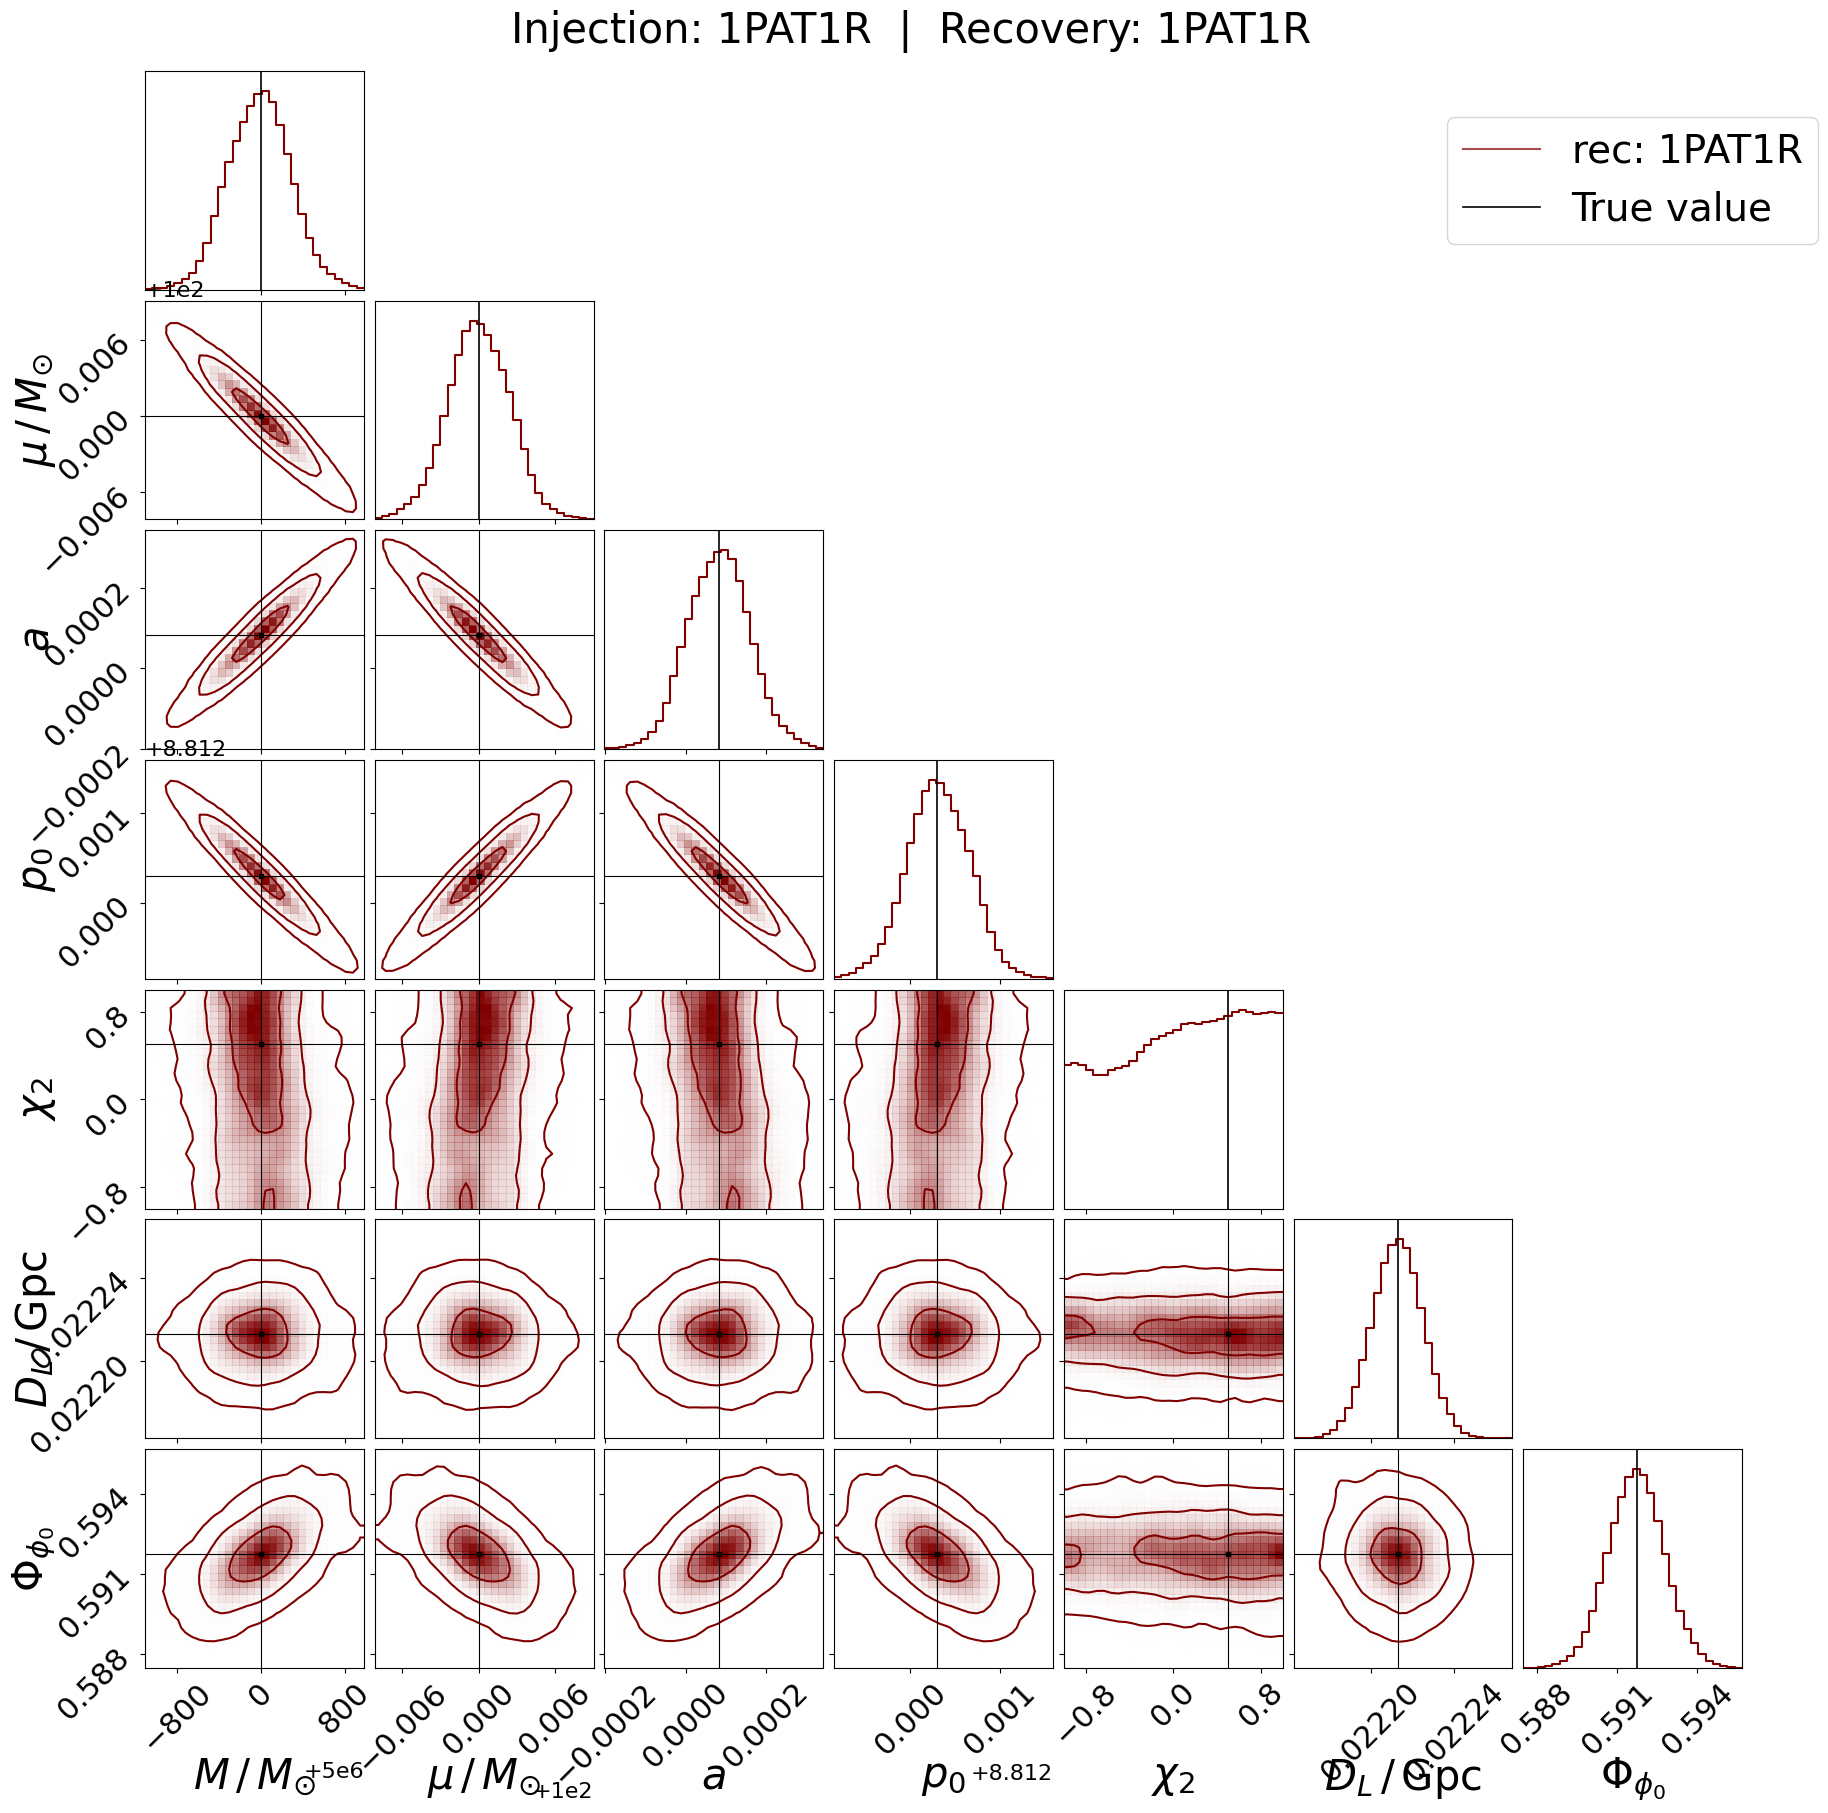

In [27]:
samples_dict_1PA = {
    r'rec: 1PAT1R': {
        'color':   'maroon',
        'samples': named_full,
    },
}

plot_name_intrinsic = f'{os.getcwd()}/Plots/review/Review_{index}_corner_intrinsic'

fig = corner_plot(
    samples_dict_1PA,
    injected_vals,
    param_names_full, 
    inj_model='1PAT1R',
    rec_model=r'1PAT1R',
    exclude_sky=True,
    plot_name=plot_name_intrinsic,
)
plt.show()

### Review test 2: edge of p0 grid


In [29]:
index = 2

In [30]:
# hardcoded path
full_1PA = f'{sampling_dir}/Review_test_2_inj_1PA_rec_1PA_2026-08-27_10-59-11'

# Load configs for each run to derive the correct parameter lists
config_full_1PA = param_load(glob.glob(os.path.join(full_1PA, '*.yaml'))[0])


# Derive sampled parameters
param_names_full, injected_vals = sampled_params_from_config(config_full_1PA)
print(f'Full 1PA params ({len(param_names_full)}): {param_names_full}')

# Locate HDF5 backends using the hard-coded paths
h5_full = glob.glob(os.path.join(full_1PA, 'SamplingResults_*.h5'))

# Validation and Loading
for label, h5_list in zip(['Full'], [h5_full]):
    if not h5_list:
        raise FileNotFoundError(f'No HDF5 found for {label} run.')
    print(f'\nLoading {label}: {h5_list[0]}')

Full 1PA params (10): ['M', 'mu', 'p0', 'chi2', 'd_L', 'theta_S', 'phi_S', 'theta_K', 'phi_K', 'Phi_phi0']

Loading Full: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/scripts/sampling_data/Review_test_2_inj_1PA_rec_1PA_2026-08-27_10-59-11/SamplingResults_Review_test_2_inj_1PA_rec_1PA_fixedx_I0_1.0_e0_0.0_a_0.0_Phi_theta0_6.13001602516006_Phi_r0_4.782381792256834_2026-08-27_10-59-11.h5


In [32]:
# Set discard (burn-in) values for each run
discard_full = 3000

# Load 'Full 1PA' samples
named_full, reader_full, log_like_full, (N_iters_full, N_temps_full, N_walkers_full, _) = \
    load_samples_named(h5_full[0], param_names_full, discard=discard_full)

# Print summary for all three
print(f'Full 1PA: {N_iters_full} iters × {N_temps_full} temps × {N_walkers_full} walkers')

Full 1PA: 809 iters × 1 temps × 70 walkers


In [33]:
injected_vals

array([5.49945055e+05, 4.41089001e+02, 2.93882870e+01, 9.00000000e-01,
       3.94259741e+00, 2.43145464e+00, 2.75755456e+00, 2.69736492e+00,
       4.38169255e+00, 5.91733729e-01])

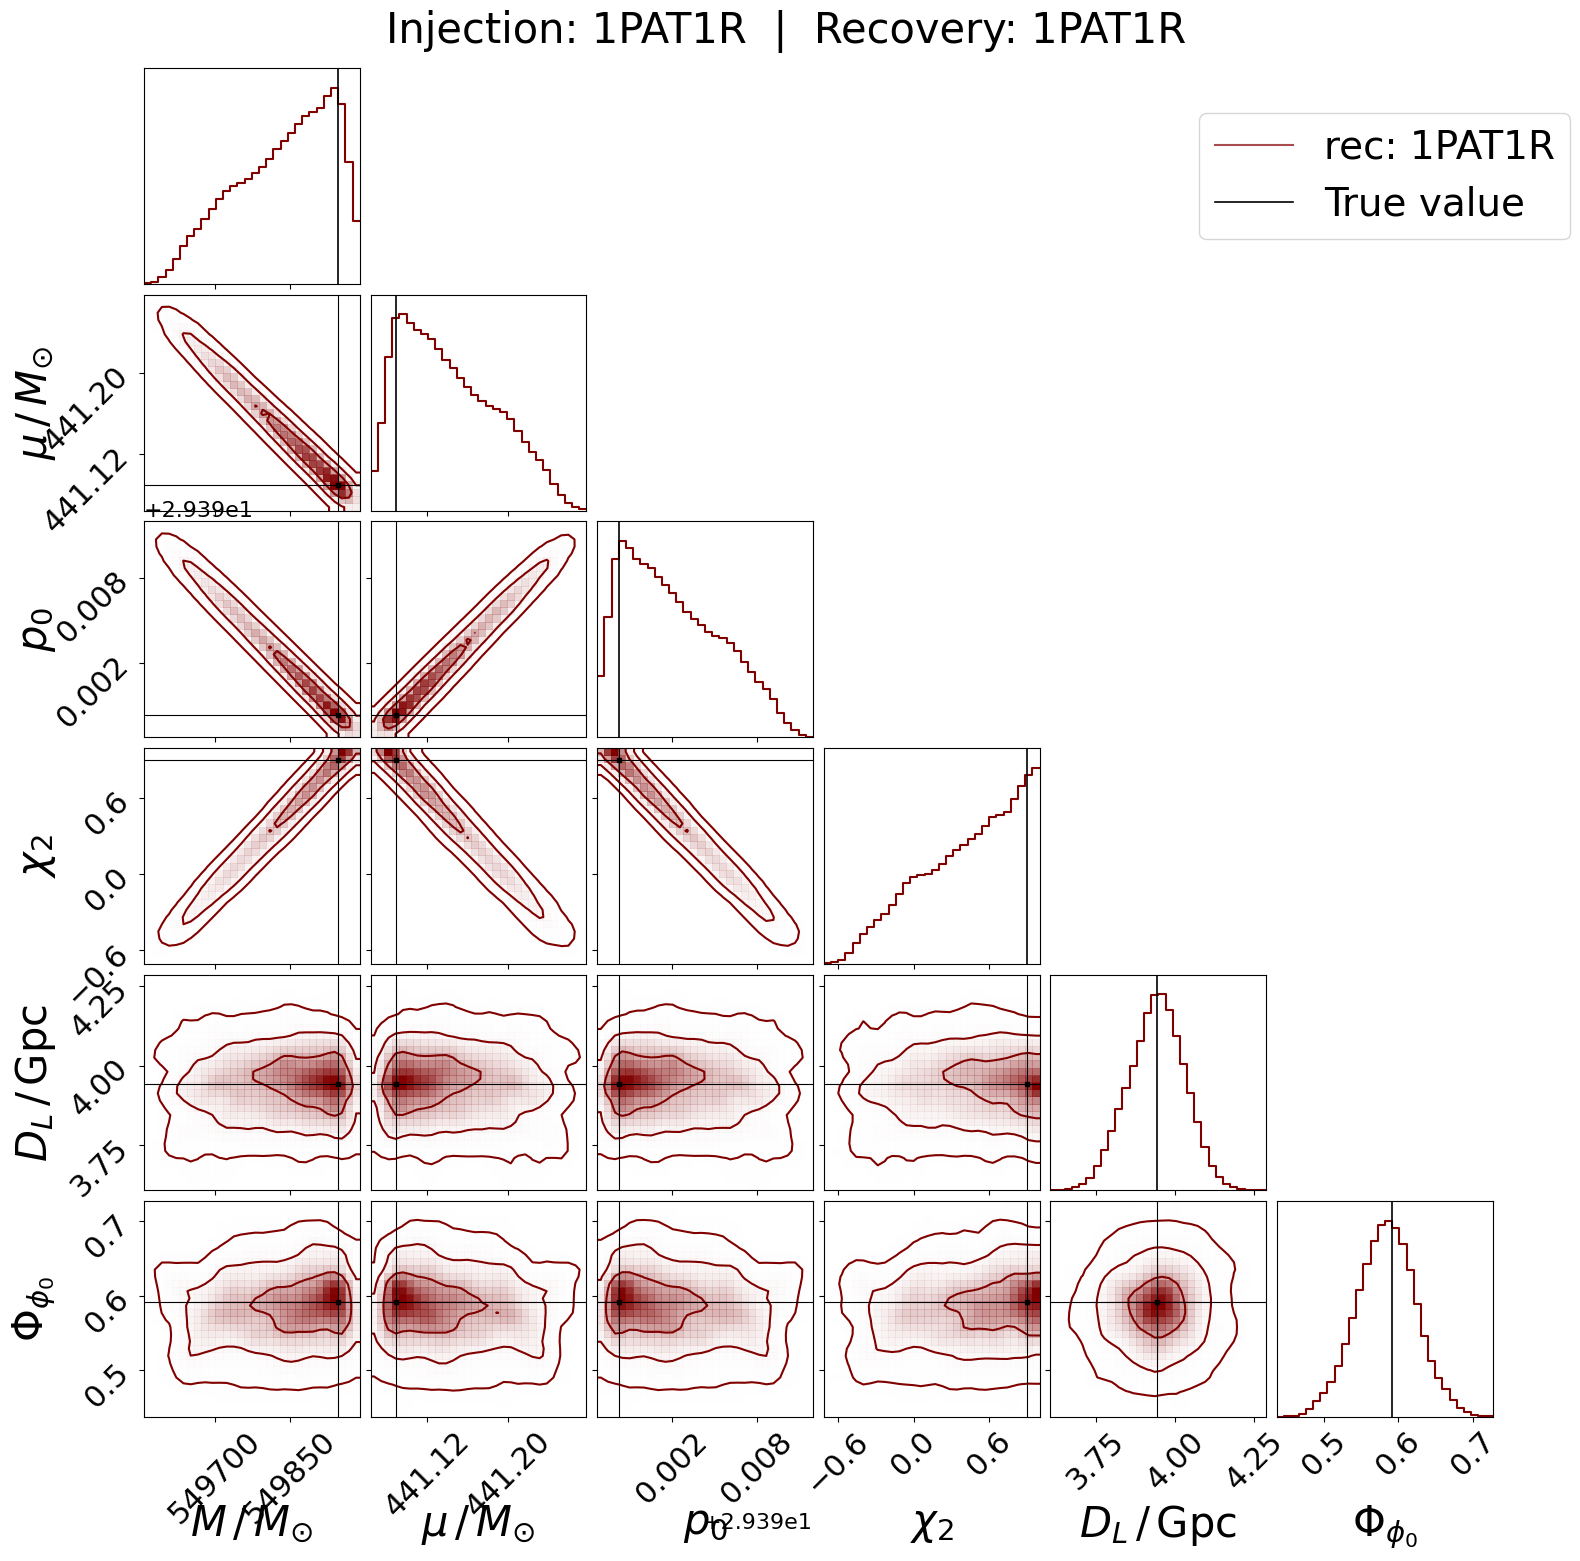

In [34]:
samples_dict_1PA = {
    r'rec: 1PAT1R': {
        'color':   'maroon',
        'samples': named_full,
    },
}

plot_name_intrinsic = f'{os.getcwd()}/Plots/review/Review_{index}_corner_intrinsic'

fig = corner_plot(
    samples_dict_1PA,
    injected_vals,
    param_names_full, 
    inj_model='1PAT1R',
    rec_model=r'1PAT1R',
    exclude_sky=True,
    plot_name=plot_name_intrinsic,
)
plt.show()

### review test 3: chi2 = 0.99
secondary spin way out of physical regime

In [37]:
index=3

In [38]:
# hardcoded path
full_1PA = f'{sampling_dir}/Review_test_3_inj_1PA_rec_1PA_2026-08-28_12-15-25'

# Load configs for each run to derive the correct parameter lists
config_full_1PA = param_load(glob.glob(os.path.join(full_1PA, '*.yaml'))[0])

# Derive sampled parameters
param_names_full, injected_vals = sampled_params_from_config(config_full_1PA)
print(f'Full 1PA params ({len(param_names_full)}): {param_names_full}')

# Locate HDF5 backends using the hard-coded paths
h5_full = glob.glob(os.path.join(full_1PA, 'SamplingResults_*.h5'))

# Validation and Loading
for label, h5_list in zip(['Full'], [h5_full]):
    if not h5_list:
        raise FileNotFoundError(f'No HDF5 found for {label} run.')
    print(f'\nLoading {label}: {h5_list[0]}')

Full 1PA params (10): ['M', 'mu', 'a', 'p0', 'd_L', 'theta_S', 'phi_S', 'theta_K', 'phi_K', 'Phi_phi0']

Loading Full: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/scripts/sampling_data/Review_test_3_inj_1PA_rec_1PA_2026-08-28_12-15-25/SamplingResults_Review_test_3_inj_1PA_rec_1PA_fixedx_I0_1.0_e0_0.0_Phi_theta0_6.13001602516006_Phi_r0_4.782381792256834_2026-08-28_12-15-25.h5


In [43]:
# Set discard (burn-in) values for each run
discard_full = 2300

# Load 'Full 1PA' samples
named_full, reader_full, log_like_full, (N_iters_full, N_temps_full, N_walkers_full, _) = \
    load_samples_named(h5_full[0], param_names_full, discard=discard_full)

# Print summary for all three
print(f'Full 1PA: {N_iters_full} iters × {N_temps_full} temps × {N_walkers_full} walkers')

Full 1PA: 697 iters × 2 temps × 40 walkers


In [44]:
index

3

In [45]:
injected_vals

array([5.04495567e+06, 5.04495567e+02, 0.00000000e+00, 1.12882870e+01,
       4.42903286e-01, 1.89000000e+00, 6.70000000e-01, 1.77530000e+00,
       3.82000000e+00, 5.91733729e-01])

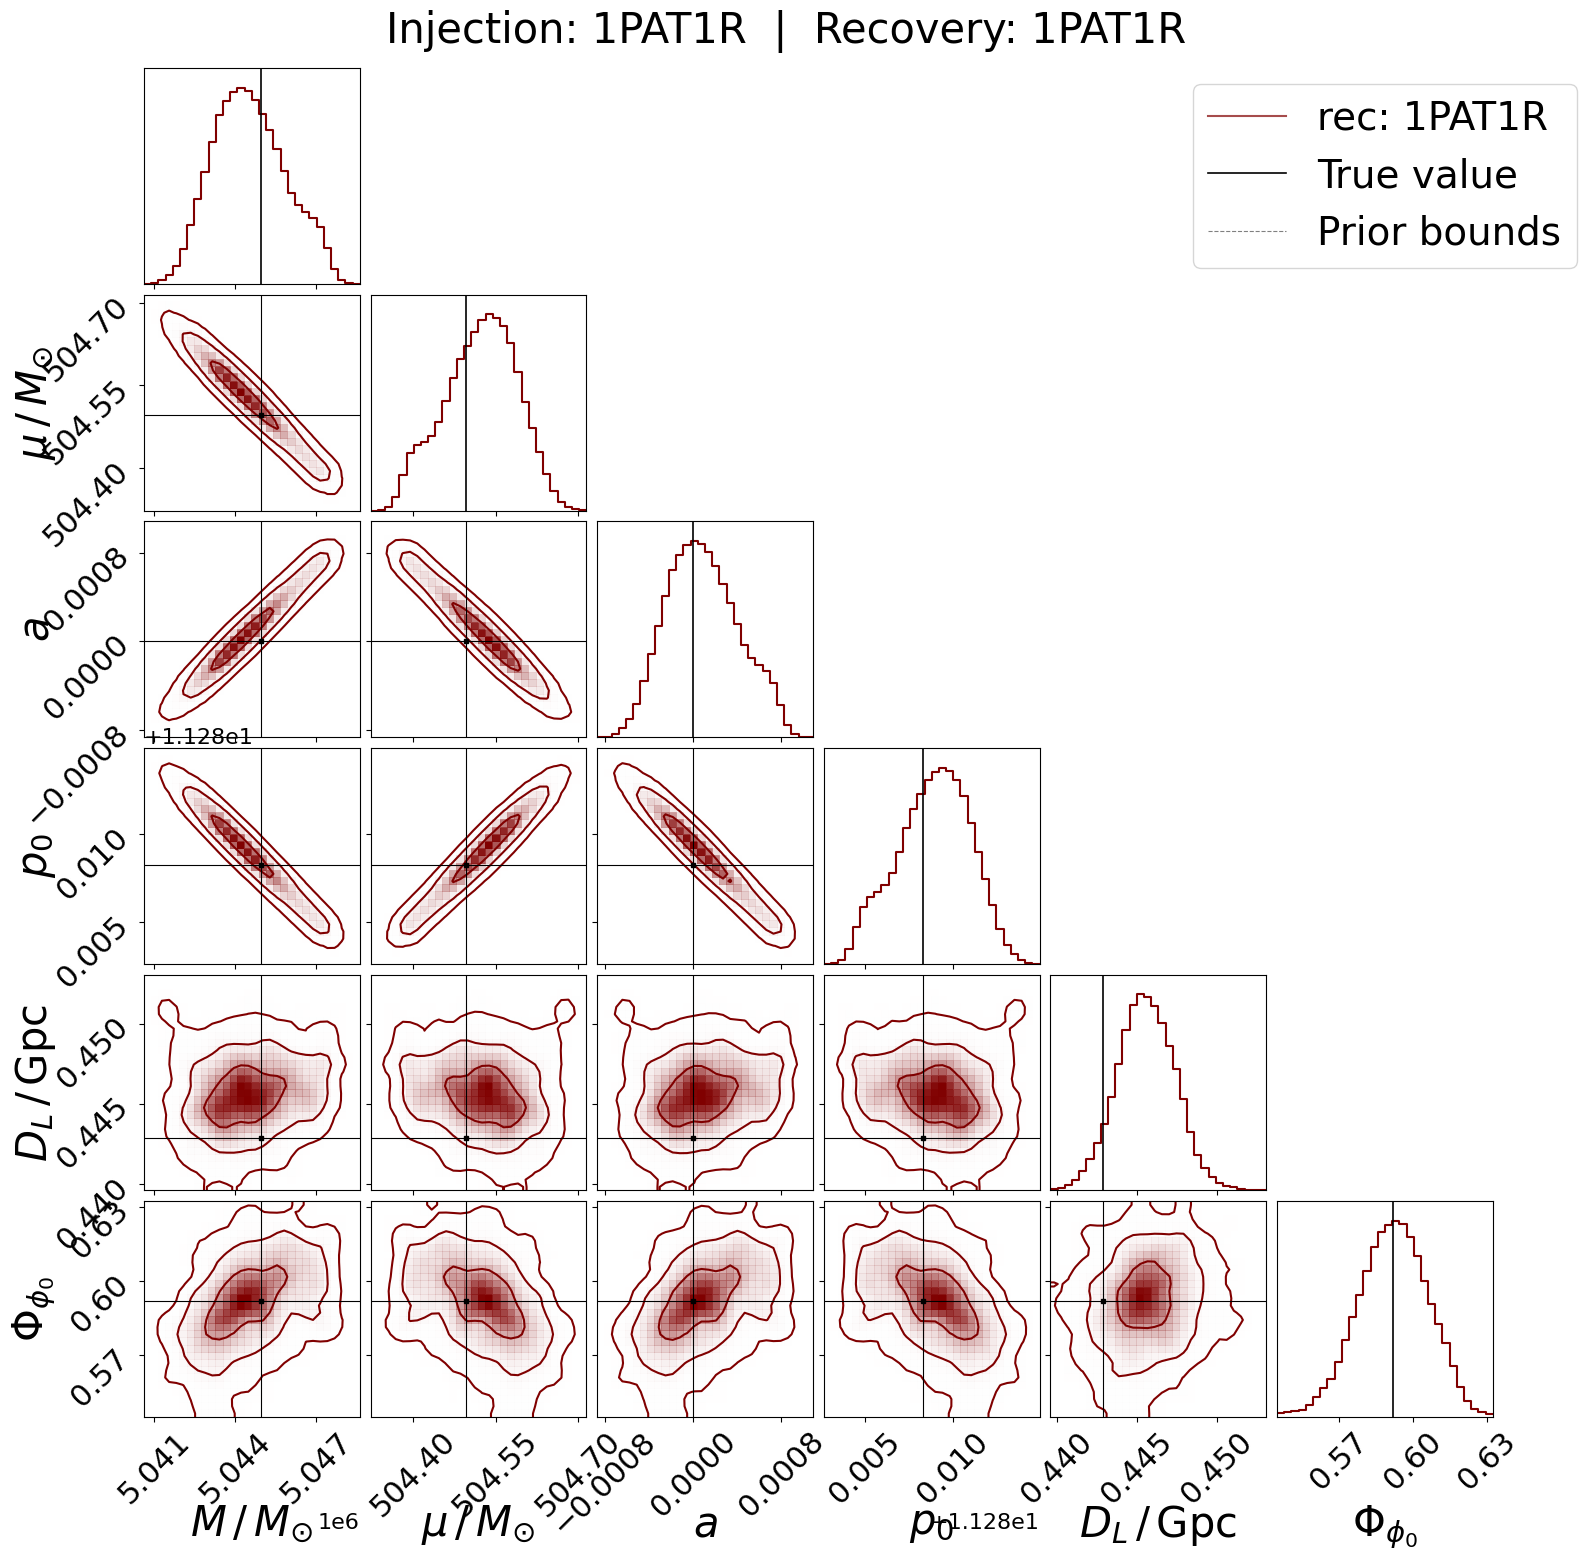

In [46]:
samples_dict_1PA = {
    r'rec: 1PAT1R': {
        'color':   'maroon',
        'samples': named_full,
    },
}

plot_name_intrinsic = f'{os.getcwd()}/Plots/review/Review_{index}_corner_intrinsic'

fig = corner_plot(
    samples_dict_1PA,
    injected_vals,
    param_names_full,
    inj_model='1PAT1R',
    rec_model=r'1PAT1R',
    exclude_sky=True,          # intrinsic + phases only
    plot_name=plot_name_intrinsic,
    range_overrides={
        'M':  1.2,         
        'mu': 1.2,   
        'a': 1.2,
        'p0': 1.2,
        'chi2': 1.0
    },
    prior_bounds=prior_bounds,
    save_dpi=100
)

plt.show()

In [47]:
# recovery SNR
